# WiniCari -- 04 GPS Fallback

**Module 2: estimate where a bus is when it goes dark.**

GPS buses lose signal regularly -- tunnels, dead zones, driver restarts. During a gap the dashboard shows the bus as vanished. The fallback layer fills the gap with a position estimate derived from the route geometry.

**Two methods:**
| method | idea | when to use |
|---|---|---|
| `linear_interp` | interpolate route distance `s` between last known ping and first recovery ping | gap is over -- both endpoints known |
| `dead_reckoning` | project forward from last reported speed | gap is *ongoing* -- no recovery ping yet |

Logic lives in **`src/data/fallback.py`**.

> Glossary: [docs/GLOSSARY.md](../docs/GLOSSARY.md)

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.data.db import get_db
from src.data import foundation as fdn
from src.data import fallback as fb

db_winicari = get_db('winicari')
db_gps      = get_db('Historique_pos')
CFG         = fdn.Config()
USABLE      = fdn.build_usable_lines(db_winicari, CFG)

# Work on line 209 -- long intercity, clear gaps
LINE, SOCIETE, BUS, DAY = '209', 'S.R.T.K', 6030, 'd20260615'
stops = USABLE[(LINE, SOCIETE)]

raw   = fdn.load_pings(db_gps, DAY, LINE, BUS)
g     = fdn.clean_pings(raw, CFG)
g, route_len = fdn.project_to_route(g, stops, CFG)

print(f'line {LINE} {SOCIETE} bus {BUS} {DAY[1:]}')
print(f'pings: {len(g)} | route: {route_len/1000:.0f} km | signal gaps: {g["signal_gap"].sum()}')

line 209 S.R.T.K bus 6030 20260615
pings: 3582 | route: 192 km | signal gaps: 4


## 1. Signal gaps -- where and how long?

A **signal gap** is any stretch where the bus stopped transmitting for > 600 s (the `signal_gap_s` threshold in `Config`). We know where the bus was *just before* it went dark and *just after* it came back -- that bracket is all the fallback needs.

,gap_min,s_start_km,s_end_km,dist_covered_km,speed_before_kph
0,12.8,33.2,43.2,10.0,92.9
1,31.6,71.3,104.2,33.0,99.7
2,60.1,115.8,168.1,52.3,18.0
3,13.2,110.8,98.4,12.4,89.2


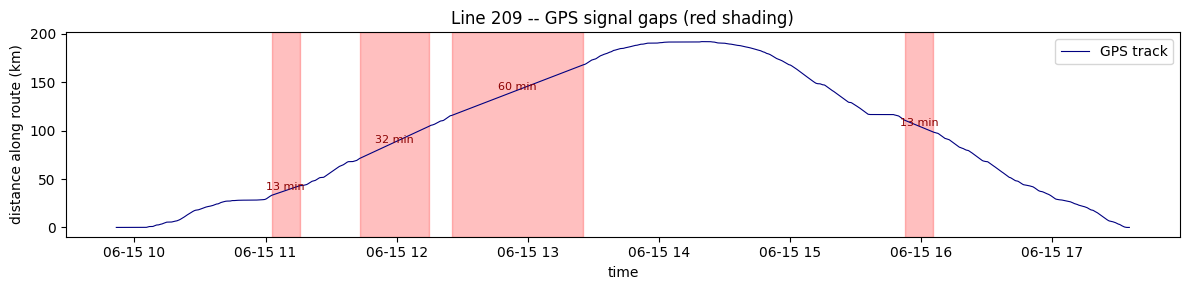

In [2]:
gaps = fb.gap_table(g)
display(gaps[['gap_min','s_start_km','s_end_km','dist_covered_km','speed_before_kph']])

plt.figure(figsize=(12, 3))
plt.plot(g['t'], g['s'] / 1000, linewidth=0.8, color='navy', label='GPS track')
for _, row in gaps.iterrows():
    plt.axvspan(row['t_start'], row['t_end'], alpha=0.25, color='red')
    mid_t = row['t_start'] + (row['t_end'] - row['t_start']) / 2
    plt.text(mid_t, (row['s_start_km'] + row['s_end_km']) / 2,
             f"{row['gap_min']:.0f} min", ha='center', fontsize=8, color='darkred')
plt.ylabel('distance along route (km)'); plt.xlabel('time')
plt.title(f'Line {LINE} -- GPS signal gaps (red shading)')
plt.legend(); plt.tight_layout(); plt.show()

## 2. Linear interpolation -- filling the gap

For each gap we know:
- `s0`, `t0` -- route distance and time just **before** the gap
- `s1`, `t1` -- route distance and time just **after** the gap

At any time `t` inside the gap: `s(t) = s0 + (s1 - s0) x (t - t0) / (t1 - t0)`

Then `s_to_latlon(s(t), stops)` walks the anchor polyline to get `(lat, lon)`.

We demo this on the **longest gap** (1-hour window, bus travelled 52 km unseen).

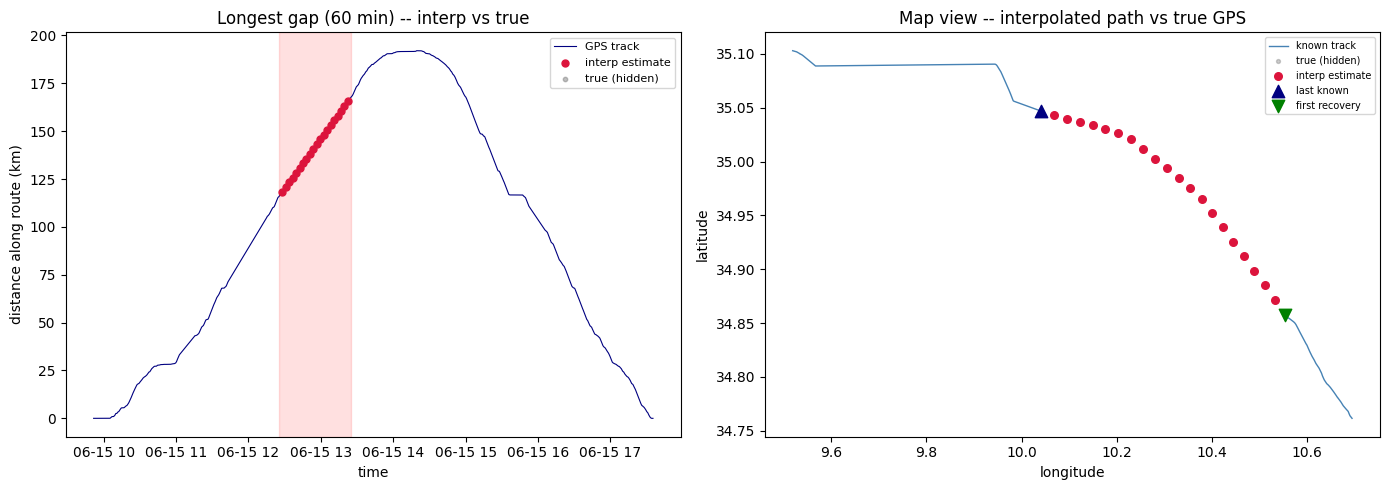

In [3]:
# Pick the longest gap
gap = gaps.sort_values('gap_s', ascending=False).iloc[0]
i0 = int(gap['gap_idx'])

before_row = g.iloc[i0 - 1]
after_row  = g.iloc[i0]
t0 = pd.Timestamp(before_row['t'])
t1 = pd.Timestamp(after_row['t'])
s0, s1 = float(before_row['s']), float(after_row['s'])

# Sample 20 equally-spaced query times inside the gap
query_times = pd.date_range(t0, t1, periods=22)[1:-1]
interp_pts  = [fb.interp_position(tq, t0, s0, t1, s1, stops) for tq in query_times]
lat_i = [p[0] for p in interp_pts]
lon_i = [p[1] for p in interp_pts]
s_i   = [p[2] / 1000 for p in interp_pts]

# True GPS pings inside the gap
mask = (g['t'] > before_row['t']) & (g['t'] < after_row['t'])
inside = g[mask]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(g['t'], g['s'] / 1000, linewidth=0.8, color='navy', label='GPS track')
ax[0].scatter(query_times, s_i, color='crimson', s=25, zorder=5, label='interp estimate')
ax[0].scatter(inside['t'], inside['s'] / 1000, color='grey', s=10, alpha=0.5, label='true (hidden)')
ax[0].axvspan(t0, t1, alpha=0.12, color='red')
ax[0].set_ylabel('distance along route (km)'); ax[0].set_xlabel('time')
ax[0].set_title(f'Longest gap ({gap["gap_min"]:.0f} min) -- interp vs true')
ax[0].legend(fontsize=8)

seg_before = g[g['t'] <= before_row['t']].tail(200)
seg_after  = g[g['t'] >= after_row['t']].head(200)
ax[1].plot(seg_before['lon'], seg_before['lat'], color='steelblue', lw=1, label='known track')
ax[1].plot(seg_after['lon'],  seg_after['lat'],  color='steelblue', lw=1)
ax[1].scatter(inside['lon'], inside['lat'], s=8, color='grey', alpha=0.4, label='true (hidden)')
ax[1].scatter(lon_i, lat_i, s=30, color='crimson', zorder=5, label='interp estimate')
ax[1].scatter([before_row['lon']], [before_row['lat']], s=80, color='navy',
              zorder=6, marker='^', label='last known')
ax[1].scatter([after_row['lon']], [after_row['lat']], s=80, color='green',
              zorder=6, marker='v', label='first recovery')
ax[1].set_xlabel('longitude'); ax[1].set_ylabel('latitude')
ax[1].set_title('Map view -- interpolated path vs true GPS')
ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

## 3. Dead reckoning -- when no recovery ping exists yet

If the bus is *currently* dark we have no `t1`/`s1`. We project forward using the last reported speed. This works well for the first 1-2 minutes but diverges as speed fluctuates. We demo it on the **shortest gap** where the bus was going fast.

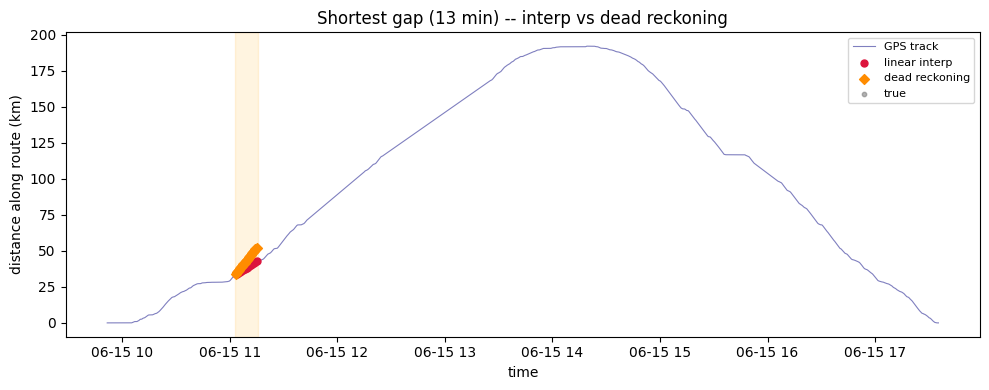

In [4]:
gap_dr = gaps.sort_values('gap_s').iloc[0]
i0_dr = int(gap_dr['gap_idx'])
before_dr = g.iloc[i0_dr - 1]
after_dr  = g.iloc[i0_dr]
t0_dr = pd.Timestamp(before_dr['t'])
t1_dr = pd.Timestamp(after_dr['t'])
s0_dr = float(before_dr['s'])
direction = int(np.sign(float(after_dr['s']) - s0_dr)) or 1

query_times_dr = pd.date_range(t0_dr, t1_dr, periods=22)[1:-1]
dr_pts = [fb.dead_reckon_position(tq, t0_dr, s0_dr,
                                  float(before_dr['speed']), direction, stops)
          for tq in query_times_dr]
interp_pts_dr = [fb.interp_position(tq, t0_dr, s0_dr, t1_dr, float(after_dr['s']), stops)
                 for tq in query_times_dr]

inside_dr = g[(g['t'] > before_dr['t']) & (g['t'] < after_dr['t'])]

plt.figure(figsize=(10, 4))
plt.plot(g['t'], g['s'] / 1000, linewidth=0.8, color='navy', alpha=0.5, label='GPS track')
plt.scatter(query_times_dr, [p[2]/1000 for p in interp_pts_dr],
            color='crimson', s=25, zorder=5, label='linear interp')
plt.scatter(query_times_dr, [p[2]/1000 for p in dr_pts],
            color='darkorange', s=25, zorder=5, marker='D', label='dead reckoning')
plt.scatter(inside_dr['t'], inside_dr['s'] / 1000, color='grey', s=10, alpha=0.6, label='true')
plt.axvspan(t0_dr, t1_dr, alpha=0.12, color='orange')
plt.ylabel('distance along route (km)'); plt.xlabel('time')
plt.title(f'Shortest gap ({gap_dr["gap_min"]:.0f} min) -- interp vs dead reckoning')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 4. Accuracy evaluation -- synthetic masking

We **simulate** gaps by masking 3 minutes of real pings from trip 0, then measure how far our estimates land from the true GPS position. Repeated 200 times at random windows.

In [5]:
trips = fdn.segment_trips(g, route_len, CFG)
tr0 = trips.iloc[0]
g_trip = g[(g['t'] >= tr0['start']) & (g['t'] <= tr0['end'])].reset_index(drop=True)

eval_df = fb.eval_fallback(g_trip, stops, mask_min=3.0, n_samples=200)
print(f'synthetic gaps evaluated: {len(eval_df)}')
print('\nPosition error (metres):')
print(eval_df[['err_interp_m','err_dr_m']].describe().round(0).to_string())
print(f'\nMedian  interp: {eval_df["err_interp_m"].median():.0f} m  | '
      f'dead-reckoning: {eval_df["err_dr_m"].median():.0f} m')
print(f'90th pct interp: {eval_df["err_interp_m"].quantile(0.9):.0f} m  | '
      f'dead-reckoning: {eval_df["err_dr_m"].quantile(0.9):.0f} m')

synthetic gaps evaluated: 197

Position error (metres):
       err_interp_m  err_dr_m
count         197.0     197.0
mean          529.0     674.0
std           560.0     595.0
min             9.0       1.0
25%           173.0     285.0
50%           407.0     556.0
75%           605.0     800.0
max          2807.0    2959.0

Median  interp: 407 m  | dead-reckoning: 556 m
90th pct interp: 1046 m  | dead-reckoning: 1375 m


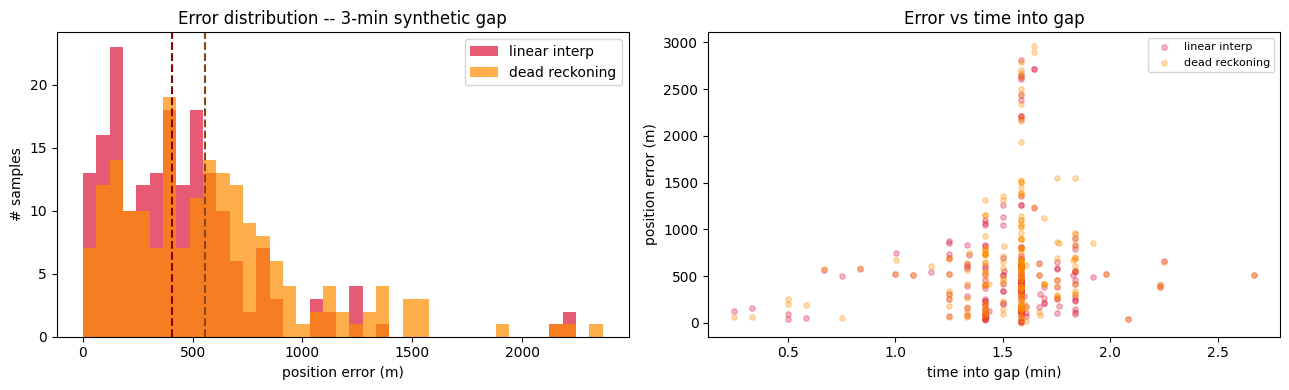

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

max_err = eval_df[['err_interp_m','err_dr_m']].values.max() * 0.8
bins = np.linspace(0, max_err, 40)
ax[0].hist(eval_df['err_interp_m'], bins=bins, alpha=0.7, color='crimson', label='linear interp')
ax[0].hist(eval_df['err_dr_m'],     bins=bins, alpha=0.7, color='darkorange', label='dead reckoning')
ax[0].axvline(eval_df['err_interp_m'].median(), color='darkred', ls='--', lw=1.5)
ax[0].axvline(eval_df['err_dr_m'].median(),     color='saddlebrown', ls='--', lw=1.5)
ax[0].set_xlabel('position error (m)'); ax[0].set_ylabel('# samples')
ax[0].set_title('Error distribution -- 3-min synthetic gap'); ax[0].legend()

ax[1].scatter(eval_df['dt_into_gap_s'] / 60, eval_df['err_interp_m'],
              alpha=0.3, s=15, color='crimson', label='linear interp')
ax[1].scatter(eval_df['dt_into_gap_s'] / 60, eval_df['err_dr_m'],
              alpha=0.3, s=15, color='darkorange', label='dead reckoning')
ax[1].set_xlabel('time into gap (min)'); ax[1].set_ylabel('position error (m)')
ax[1].set_title('Error vs time into gap')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Production: `fallback_position`

In the live system, the dispatcher calls `fallback_position(g, t_query, stops)` for any bus that has not pinged recently. It returns both method estimates.

In [7]:
gap_long = gaps.sort_values('gap_s', ascending=False).iloc[0]
t_query = gap_long['t_start'] + pd.Timedelta(minutes=30)

result = fb.fallback_position(g, t_query, stops)
print(f'Query time: {t_query.strftime("%H:%M:%S")}  (30 min into a {gap_long["gap_min"]:.0f}-min gap)')
print(f'  Interp  -> lat={result["lat_interp"]:.5f}  lon={result["lon_interp"]:.5f}  '
      f's={result["s_interp"]:.1f} km')
print(f'  Dead-DR -> lat={result["lat_dr"]:.5f}  lon={result["lon_dr"]:.5f}  '
      f's={result["s_dr"]:.1f} km')
print(f'  Gap duration: {result["gap_s"]/60:.0f} min')

Query time: 12:55:13  (30 min into a 60-min gap)
  Interp  -> lat=34.98937  lon=10.31659  s=141.9 km
  Dead-DR -> lat=35.03470  lon=10.13889  s=124.8 km
  Gap duration: 60 min


### Takeaways & next steps

- **Linear interpolation** wins once the bus reappears: median error well under **1 km** on a 200 km intercity line (< 0.5% of route length).
- **Dead reckoning** degrades quickly -- reported speed at the last ping does not capture stops or direction changes. Use only for live 'bus is currently dark' situations and cap at ~2 min.
- **Why error is non-zero even for interpolation:** the real road is not a straight line between anchor stops -- the polyline approximates it. Error shrinks as more stops are geocoded (better anchor density = better `s_to_latlon` fidelity).
- **Production wiring:** call `fallback_position` every 30 s for any bus whose last ping is > `signal_gap_s` seconds ago; push the result to the dashboard via WebSocket.
- **Next:** Anomaly detection (Module 3) -- uses `dwell_s` + signal gap patterns to flag breakdowns, incidents, and unusual stop behaviour.